# Heart Disease UCI Dataset — Exploratory Data Analysis

**Course:** Machine Learning Operations (MLOps) — AIMLCZG523, BITS Pilani WILP M.Tech. AIML
**Assignment:** Assignment 01 — MLOps Experimental Learning Assignment
**Task covered:** Task 1 — Data Acquisition & Exploratory Data Analysis (EDA) [5 marks]

## Objective
Load the raw UCI Heart Disease (Cleveland) dataset, clean it, and perform exploratory data
analysis to understand feature distributions, missingness, correlations, and class balance
before any modelling decisions are made.

## Dataset
- **Source:** UCI Machine Learning Repository — Heart Disease dataset (Cleveland subset)
- **Rows:** 303 patients
- **Features:** 13 clinical features (age, sex, chest pain type, resting blood pressure,
  cholesterol, fasting blood sugar, resting ECG, max heart rate, exercise-induced angina,
  ST depression, slope, number of major vessels, thalassemia)
- **Target:** binary — presence (1) / absence (0) of heart disease (binarized from the
  original 0–4 severity scale, see `src/download_data.py`)


In [1]:
# Imports
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))
from src.download_data import download_raw_data, clean_and_process, save_processed

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


## 1. Data Acquisition

We reuse the same `src/download_data.py` module used by the production training
pipeline (`src/train.py`), so the EDA notebook and the automated pipeline are guaranteed
to see identical data — there is only ONE code path that downloads and cleans the raw
UCI file.


In [2]:
raw_path = download_raw_data(dest_path="../data/raw/processed.cleveland.data")
df = clean_and_process(raw_path)
save_processed(df, dest_path="../data/processed/heart_disease_clean.csv")
print(f"Shape: {df.shape}")
df.head()


[download_data] Raw file already exists at ../data/raw/processed.cleveland.data, skipping download.
[download_data] Saved cleaned dataset (303 rows, 14 cols) to ../data/processed/heart_disease_clean.csv
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Missing Value Analysis

The raw UCI file encodes missing values as the literal string `"?"`. After cleaning
(`clean_and_process`), these become proper `NaN`s. Only two columns have any missingness:
`ca` (number of major vessels) and `thal` (thalassemia test result) — a handful of rows
each, consistent with the well-documented UCI dataset quality.


In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0]
missing_summary


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


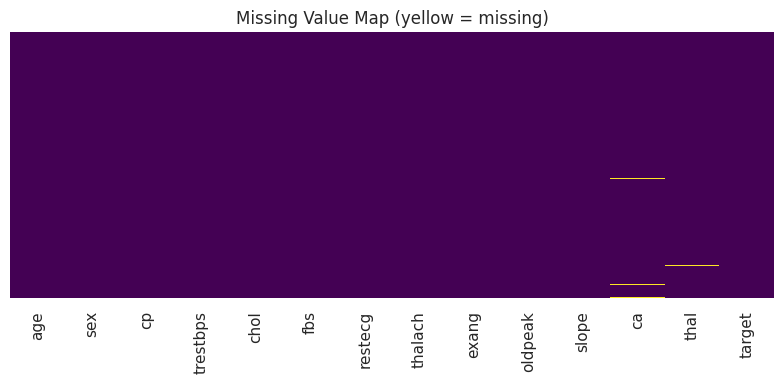

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (yellow = missing)")
plt.tight_layout()
plt.savefig("../reports/figures/eda_missing_value_map.png", dpi=150)
plt.show()


## 3. Class Balance

The target is reasonably well balanced (~54% no-disease vs ~46% disease), which means
we do **not** need aggressive class-imbalance techniques (e.g. SMOTE) — a stratified
train/test split and stratified cross-validation (used in `src/train.py`) are sufficient.


/sessions/stoic-lucid-turing/tmp/ipykernel_6/3891833890.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])


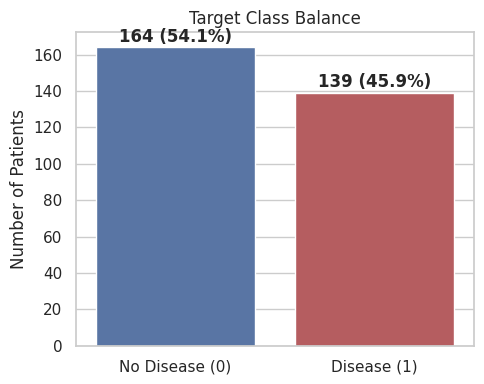

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["target"].value_counts().sort_index()
labels = ["No Disease (0)", "Disease (1)"]
sns.barplot(x=labels, y=counts.values, ax=ax, palette=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 3, f"{v} ({v/len(df)*100:.1f}%)", ha="center", fontweight="bold")
ax.set_ylabel("Number of Patients")
ax.set_title("Target Class Balance")
plt.tight_layout()
plt.savefig("../reports/figures/eda_class_balance.png", dpi=150)
plt.show()


## 4. Numeric Feature Distributions (Histograms)

We look at the five continuous clinical measurements: age, resting blood pressure
(`trestbps`), cholesterol (`chol`), max heart rate achieved (`thalach`), and ST depression
(`oldpeak`). Split by target class to spot early separating signal.


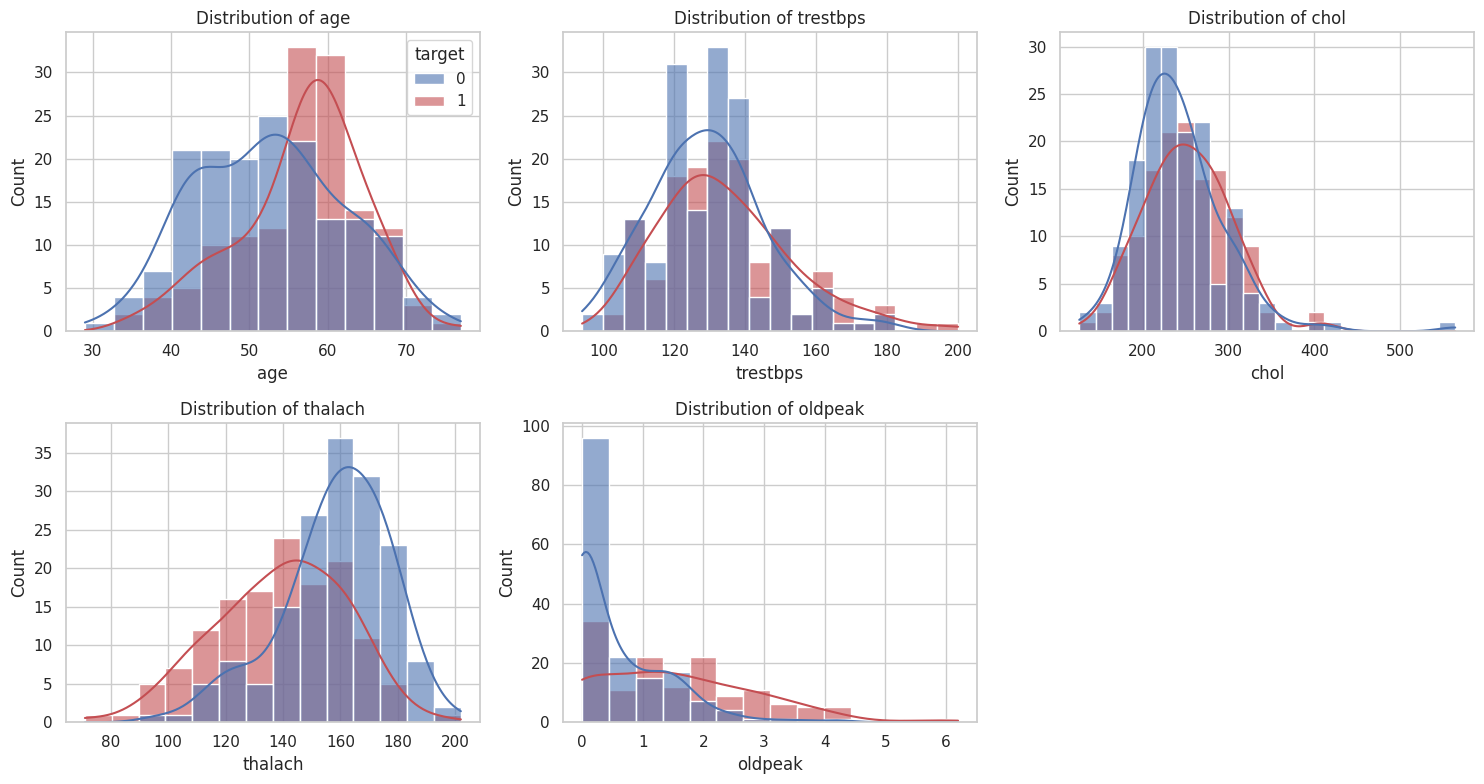

In [6]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feat in enumerate(numeric_features):
    sns.histplot(data=df, x=feat, hue="target", kde=True, ax=axes[i],
                 palette={0: "#4C72B0", 1: "#C44E52"}, alpha=0.6, legend=(i == 0))
    axes[i].set_title(f"Distribution of {feat}")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/figures/eda_numeric_histograms.png", dpi=150)
plt.show()


**Observations:**
- `thalach` (max heart rate achieved) shows the clearest separation — patients with
  disease tend to have a *lower* max heart rate achieved during exercise testing.
- `oldpeak` (ST depression) is right-skewed, and higher values are associated with disease
  presence — consistent with established cardiology literature.
- `age` and `chol` show milder separation but still shift the disease-present distribution
  slightly older / higher.


## 5. Categorical Feature Relationships

`cp` (chest pain type), `exang` (exercise-induced angina), `sex`, and `thal` are
particularly informative categorical predictors in this dataset.


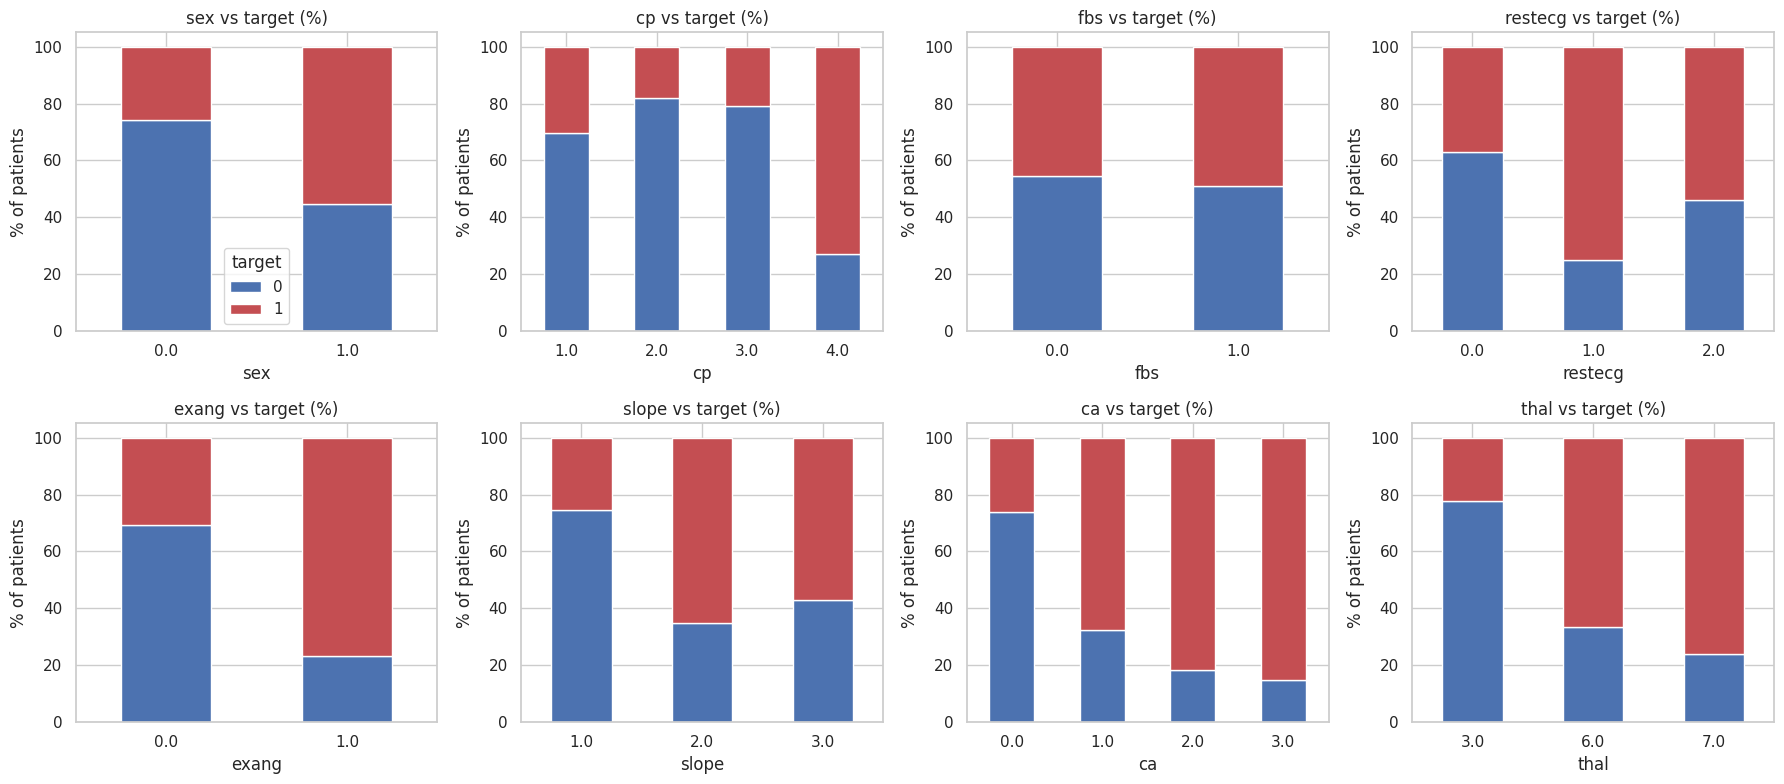

In [7]:
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(categorical_features):
    ct = pd.crosstab(df[feat], df["target"], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["#4C72B0", "#C44E52"], legend=(i == 0))
    axes[i].set_title(f"{feat} vs target (%)")
    axes[i].set_ylabel("% of patients")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/eda_categorical_relationships.png", dpi=150)
plt.show()


## 6. Correlation Heatmap

Pearson correlation across all numeric/encoded columns (including target), to spot
multicollinearity between predictors and identify which raw features correlate most
strongly with the target before feature engineering.


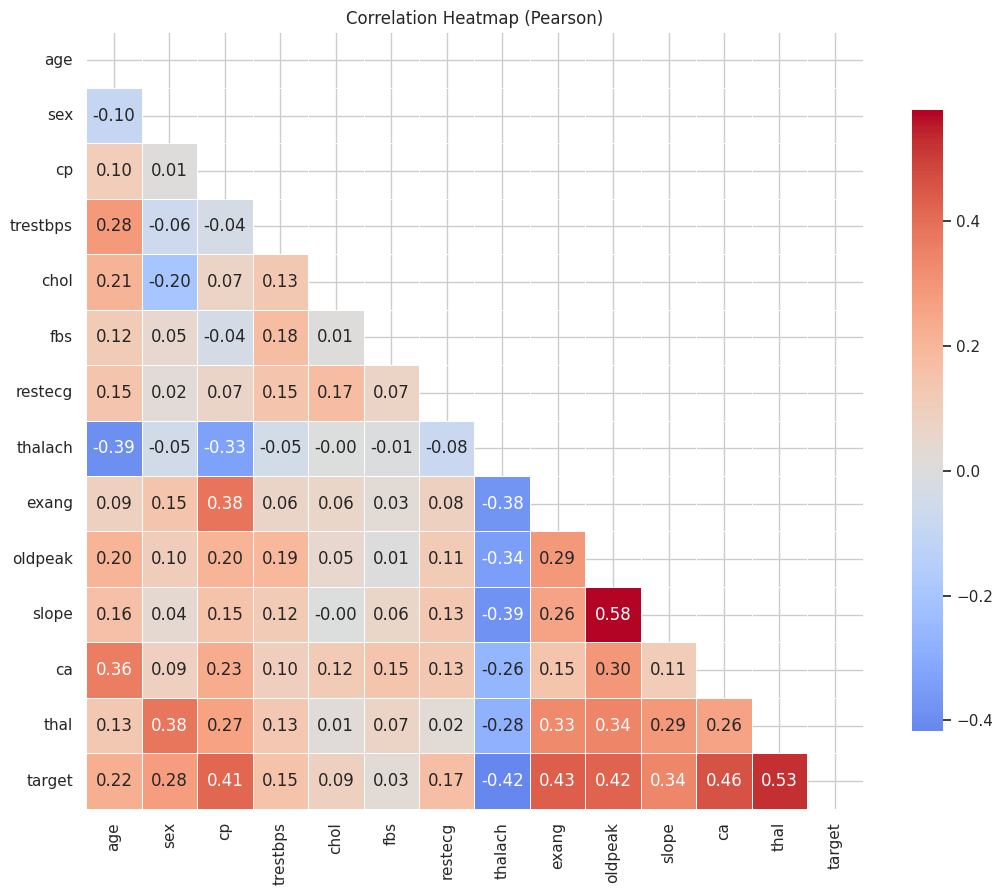

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap (Pearson)")
plt.tight_layout()
plt.savefig("../reports/figures/eda_correlation_heatmap.png", dpi=150)
plt.show()


In [9]:
target_corr = corr["target"].drop("target").sort_values(key=abs, ascending=False)
print("Features most correlated with target (by absolute Pearson r):")
target_corr


Features most correlated with target (by absolute Pearson r):


thal        0.525689
ca          0.460442
exang       0.431894
oldpeak     0.424510
thalach    -0.417167
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
Name: target, dtype: float64

**Observations:**
- `cp` (chest pain type), `thalach` (max heart rate), `exang` (exercise angina), and
  `oldpeak` show the strongest linear association with the target — consistent with the
  histogram/crosstab findings above.
- No pair of PREDICTOR features shows extreme multicollinearity (|r| > 0.8), so we do not
  need to drop any raw feature purely for redundancy before modelling.


## 7. Summary Statistics


In [10]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


## 8. Key EDA Takeaways → Feature Engineering Decisions

1. **Missingness is minor** (`ca`: 4 rows, `thal`: 2 rows) → median/mode imputation inside
   a `sklearn.Pipeline` is sufficient; no rows need to be dropped (see `src/features.py`).
2. **Class balance is acceptable** (~54/46) → stratified train/test split + stratified CV,
   no resampling needed (see `src/train.py`).
3. **Numeric features have different scales** (e.g. `chol` ~130–560 vs `oldpeak` ~0–6.2) →
   `StandardScaler` required before Logistic Regression.
4. **Categorical codes are NOT ordinal** (e.g. `cp` 1–4 are distinct chest-pain types, not a
   severity scale) → one-hot encoding, not treating them as raw integers.
5. **`thalach`, `oldpeak`, `cp`, and `exang`** are the strongest early predictors — worth
   watching in the trained models' feature-importance / coefficient outputs
   (see `notebooks/02_model_training.ipynb`).

This notebook's outputs feed directly into `src/features.py` (preprocessing pipeline) and
`src/train.py` (model training + MLflow tracking), which are executed as standalone,
testable scripts rather than being re-implemented inside this notebook — avoiding logic
duplication and train/serve skew.
